Evaluate the performance of a store trial which was performed in stores 77, 86 and 88.  
Trail period: Feb 2019 - April 2019

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

transactions_df = pd.read_csv(r'E:\Projects\DataAnalysis\Forage\Quantium\data\processed\clean_QVI_transactions_data.csv')

Filter necessary data

In [2]:
transactions_df.nunique()
df = transactions_df.loc[transactions_df['IS_CHIP']].copy()
df.dtypes
df['DATE'] = pd.to_datetime(df['DATE'])
df['FISCAL_MONTH'] = (df['DATE'].dt.month - 7) % 12 + 1
# Business' fiscal year starts july-1st and ends june-30th.
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,BRAND_NAME,MISSING_BRAND_NAME,PACK_SIZE,IS_CHIP,FISCAL_MONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,Natural ChipCo,False,175,True,4
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,CCs,False,175,True,11
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,Smiths,False,170,True,11
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,Smiths,False,175,True,2
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,Kettle,False,150,True,2


In [3]:
# 271 stores in total
# We only have to use stores that are operational for the whole year(sales in every month)
store_month_count = df.groupby('STORE_NBR')['FISCAL_MONTH'].nunique()
print(store_month_count.unique())

store_month_count.loc[[77,86,88]]
# The trail stores have whole year sales. Trail starts from Feb

valid_stores = store_month_count[store_month_count == 12].index
df = df[df['STORE_NBR'].isin(valid_stores)]

assert (df.groupby('STORE_NBR')['FISCAL_MONTH'].nunique() == 12).all()

[12  2 11  1 10  3]


In [4]:
df['STORE_NBR'].nunique()
# 259 stores which were operational for the whole fiscal year.

259

- Boundaries for comparing Trail stores.
- Defined metrics:
    - Monthly overall sales revenue
    - Monthly number of customers
    - Monthly number of transactions per customer (later excluded — see below)
- Check stores with similar metrics to trail stores 77, 86, 88 prior to Feb

In [5]:
prior_feb_mask = (df['FISCAL_MONTH'] < 8)
monthly_store_stats = df[prior_feb_mask].groupby(['FISCAL_MONTH','STORE_NBR']).agg(
    revenue = ('TOT_SALES','sum'),
    customers = ('LYLTY_CARD_NBR','nunique'),
    order_volume = ('TXN_ID','count')
)
monthly_store_stats['avg_txns_per_cust'] = monthly_store_stats['order_volume'] / monthly_store_stats['customers']

In [6]:
for store in df['STORE_NBR'].unique():
    store_std = monthly_store_stats['avg_txns_per_cust'].xs(store,level='STORE_NBR').std()
    if store_std == 0:
        print(f"store: {store} - {store_std}")

store: 161 - 0.0
store: 52 - 0.0
store: 61 - 0.0
store: 127 - 0.0
store: 132 - 0.0
store: 224 - 0.0
store: 263 - 0.0
store: 267 - 0.0
store: 14 - 0.0
store: 42 - 0.0
store: 99 - 0.0
store: 139 - 0.0
store: 146 - 0.0
store: 159 - 0.0
store: 198 - 0.0
store: 204 - 0.0
store: 258 - 0.0


- some stores have a constant avg_txns_per_cust across pre-trial months, producing an undefined correlation coefficient. Hence, excluded from further calculations.
Only revenue and customer counts will be used for correlation.

In [7]:
# Figure out control stores (stores with similar metrics to our trial stores)
# Using pearson correlation
def calculate_correlation(input_table, metric_col, trial_store):
    trial_data = input_table.xs(trial_store, level='STORE_NBR')[metric_col]
    correlation_table = []

    for store in input_table.index.get_level_values('STORE_NBR').unique():
        if store in [trial_store, 77, 86, 88]:
            continue

        control_data = input_table.xs(store, level='STORE_NBR')[metric_col]
        r, _ = stats.pearsonr(trial_data, control_data)
        correlation_table.append({
            'Trial Store': trial_store,
            'Control Store': store,
            f'corr_{metric_col}': r 
        })

    return pd.DataFrame(correlation_table)

In [8]:
# We have 3 metrics, calculate an average across all 3 metrics to define a control store
def avg_correlation(trial_store):
    corr_tables = []

    for metric in ['revenue', 'customers']:
        corr = calculate_correlation(monthly_store_stats, metric, trial_store)
        corr_tables.append(corr)

    combined = (corr_tables[0].merge(corr_tables[1], on=['Trial Store', 'Control Store']))
    combined['combined_score'] = combined[['corr_revenue', 'corr_customers']].mean(axis=1, skipna=True)

    return combined.sort_values('combined_score', ascending=False)

print(avg_correlation(77)[:3])
print(avg_correlation(86)[:3])
print(avg_correlation(88)[:3])

     Trial Store  Control Store  corr_revenue  corr_customers  combined_score
217           77            233      0.973643        0.965682        0.969663
108           77            119      0.775571        0.919064        0.847318
151           77            162      0.857584        0.811532        0.834558
     Trial Store  Control Store  corr_revenue  corr_customers  combined_score
144           86            155      0.869532        0.829086        0.849309
104           86            114      0.750924        0.855045        0.802985
243           86            260      0.827631        0.745916        0.786774
     Trial Store  Control Store  corr_revenue  corr_customers  combined_score
12            88             14      0.479135        0.967364        0.723249
191           88            204      0.871969        0.458144        0.665057
0             88              1      0.842232        0.429977        0.636105


Trial and Control Store Pairs
- 77 : 233
- 86 : 155
- 88 : 14  

Compare Performance of Trial Stores to their subsequent Control Stores - during the trial period.

In [9]:
pair_one = [77,233]
pair_two = [86,155]
pair_three = [88,14]

def calculate_pre_trial_stats(pair):
    pair_pre_trial_mask = (df['FISCAL_MONTH'] < 8) & (df['STORE_NBR'].isin(pair))
    pre_trial_stats = df[pair_pre_trial_mask].groupby(['STORE_NBR','FISCAL_MONTH']).agg(
        revenue = ('TOT_SALES','sum'),
        customers = ('LYLTY_CARD_NBR', 'nunique')
    )
    return pre_trial_stats

In [10]:
def visualize_metric_similarity(pre_trial_stats):
    fig, axs = plt.subplots(2,1)

    sns.lineplot(
        data = pre_trial_stats,
        x = pre_trial_stats.index.get_level_values('FISCAL_MONTH'),
        y = 'revenue',
        hue = pre_trial_stats.index.get_level_values('STORE_NBR'),
        palette = ['teal', 'cadetblue'],
        ax = axs[0]
    )
    axs[0].set_xticks(
        pre_trial_stats.index.get_level_values('FISCAL_MONTH').unique(), 
        ['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan']
        )

    sns.barplot(
        data = pre_trial_stats,
        x = pre_trial_stats.index.get_level_values('FISCAL_MONTH'),
        y = 'customers',
        hue = pre_trial_stats.index.get_level_values('STORE_NBR'),
        palette = ['teal', 'cadetblue'],
        ax = axs[1],
    )

    plt.tight_layout()
    plt.show()

In [11]:
# The metrics needs to be scaled before we can compare them
def calculate_percent_change_with_scaled_metrics(pair):
    pre_trial_stats = calculate_pre_trial_stats(pair)
    scaling_factor = (pre_trial_stats.loc[pair[0]] / pre_trial_stats.loc[pair[1]]).mean()
    print(scaling_factor)

    pair_trial_mask = (((df['FISCAL_MONTH'] >= 8) & (df['FISCAL_MONTH'] <= 10 )) & (df['STORE_NBR'].isin(pair)))
    pair_trial_stats = df[pair_trial_mask].groupby(['STORE_NBR','FISCAL_MONTH']).agg(
        revenue = ('TOT_SALES','sum'),
        customers = ('LYLTY_CARD_NBR', 'nunique')
    )

    control_store_scaled_rev = pair_trial_stats.loc[pair[1],'revenue'] * scaling_factor['revenue']
    print(((pair_trial_stats.loc[pair[0],'revenue'] - control_store_scaled_rev) / control_store_scaled_rev) * 100)

    control_store_scaled_cust = pair_trial_stats.loc[pair[1], 'customers'] * scaling_factor['customers']
    print(((pair_trial_stats.loc[pair[0], 'customers'] - control_store_scaled_cust) / control_store_scaled_cust) * 100)


Pair 1

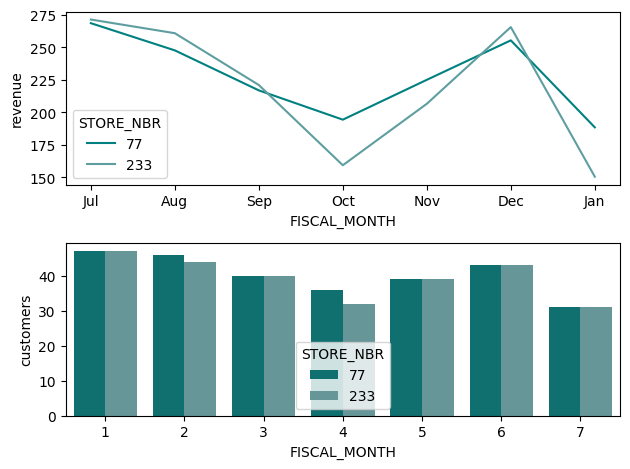

In [12]:
visualize_metric_similarity(calculate_pre_trial_stats(pair_one))

In [13]:
calculate_percent_change_with_scaled_metrics(pair_one)

revenue      1.063242
customers    1.024351
dtype: float64
FISCAL_MONTH
8     -9.826005
9     32.849735
10    68.341319
Name: revenue, dtype: float64
FISCAL_MONTH
8     -7.025885
9     28.304279
10    69.936022
Name: customers, dtype: float64


- Clear growth across both metrics - compared to the scaled control store metrics
    - Feb: 9.8% and 7% decline in revenue and number of customers (Introduction period for the change)
    - March: 32.8% and 28.3% growth in revenue and number of customers (customers have adapted and the trial seems positive)
    - April: 68.3% and 69.9% growth in revenue and number of customers (increase in revenue and customers, suggesting a possible trial effect)

Pair 2

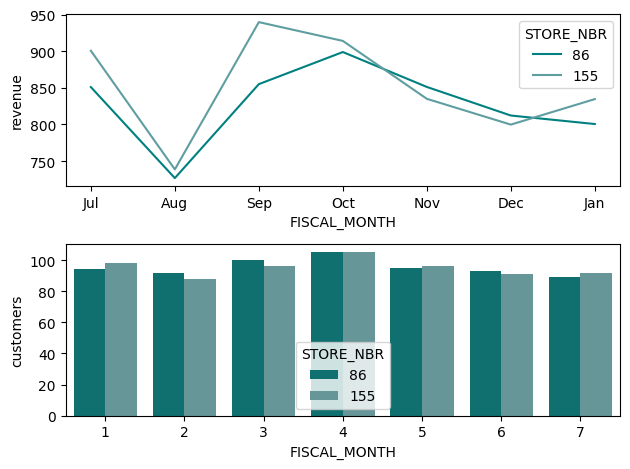

In [14]:
visualize_metric_similarity(calculate_pre_trial_stats(pair_two))

In [15]:
calculate_percent_change_with_scaled_metrics(pair_two)

revenue      0.973769
customers    1.003608
dtype: float64
FISCAL_MONTH
8      5.349226
9     26.579778
10     3.155660
Name: revenue, dtype: float64
FISCAL_MONTH
8     13.720108
9     18.254630
10     6.068893
Name: customers, dtype: float64


- The change is not as high as in store 77

Pair 3

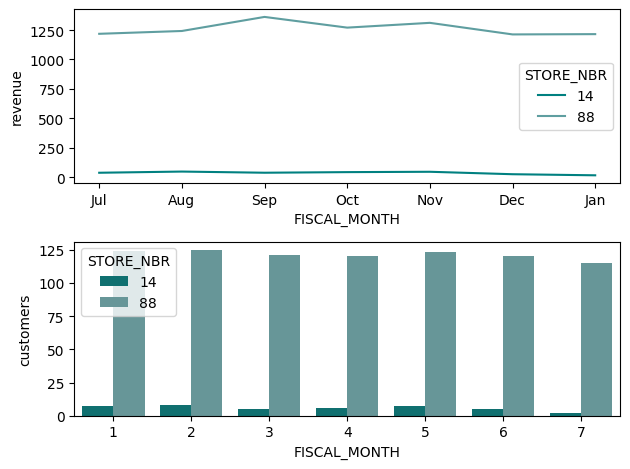

In [16]:
visualize_metric_similarity(calculate_pre_trial_stats(pair_three))

In [17]:
calculate_percent_change_with_scaled_metrics(pair_three)

revenue      41.027335
customers    25.230102
dtype: float64
FISCAL_MONTH
8      -5.083134
9     170.883703
10     85.552311
Name: revenue, dtype: float64
FISCAL_MONTH
8      -3.290126
9     163.574043
10     57.219605
Name: customers, dtype: float64


- The changes in metrics are not fully reliable
    - 170.8% and 163.6% growth in March (revenue and number of customers)
- Possibly due to not having the ideal control store for store 88
    - combined correlation score - 0.723249 and revenue correlation - 0.479135.

The sample size is not enough to prove the significance of change through a statistical t or Mann-Whitney U test

**Summary of trial performance**
- Store 77 showed the strongest results: an initial dip in February (-9.8% revenue, -7% customers), followed by a clear recovery and growth in March (+32.8%, +28.3%) and a large jump in April (+68.3%, +69.9%)
- Store 86 showed consistent, moderate positive growth across all three months (+5.3% to +26.6% revenue, +6.1% to +18.3% customers), without the initial dip seen in Store 77
- Store 88's results were inconclusive - the extreme March spike (+170.9% revenue, +163.6% customers) is unreliable given the weak control store match (revenue correlation only 0.48)

**Overall pattern**
- Two out of three trial stores (77 and 86) showed a consistent positive trend in both revenue and customer numbers during the trial period relative to their scaled control stores.
- The direction of the effect is consistently positive across both reliable pairs, even though the magnitude and pattern (Store 77's dip-then-surge vs Store 86's steady growth) differed.

**Limitations**
- No formal statistical significance testing was conducted due to the small sample size (3 trial months), so these results should be read as directional/observational evidence rather than statistically proven causation
- Store 88's pairing with Store 14 was the weakest match (correlation 0.72 combined, 0.48 revenue), making its results the least trustworthy of the three
- A longer trial period or a larger pool of trial stores would substantially strengthen confidence in these findings

#### **Conclusion**

**Recommendation**  
The positive trend in 2 of 3 stores is encouraging enough to justify either extending the trial duration for more data, or running the trial in additional stores with a stronger control store match (especially to address the Store 88 gap), before committing to a full rollout